# Testing the FID fix

**Why this notebook exists.** On the leaderboard, PDS, MSE, JAC and REACH sit near 0, but
**FID is −1.18**, which alone accounts for almost all of the ~−0.2 overall score
(overall = mean of six metrics, and −1.18 / 6 ≈ −0.20).

**What FID measures** ([official brief](https://github.com/ArcInstitute/cell-eval2/blob/main/docs/vcc2026_metrics/vcc2026-metrics-brief.md)):
for each perturbation, the scorer runs a **Wilcoxon rank-sum test** of your predicted cells
against the reference **control cells** (counts normalized per cell to 10⁶, genes with
≥ 5 CPM in controls, Benjamini–Hochberg per perturbation). Then

$$F_p = \frac{k}{\max(n_\text{pred},\ n_\text{real})}$$

where $k$ = called genes whose direction matches the reference. Calling **too few** genes
caps $k$ at $n_\text{pred}$ while the denominator stays at $n_\text{real}$, so FID stays low
no matter how accurate the calls are.

**The suspicion:** our predicted effects are tiny (ridge + averaging over screens shrink them),
and `np.round` erases small changes on low-count genes (any multiplier between 0.5 and 1.5
leaves a count of 1 unchanged). So the test finds almost nothing.

**What this notebook does:** for a sample of challenge targets, it generates cells exactly as
`write_submission` would, runs the same DE test the scorer runs, and counts the calls.
It compares several **cell-generation settings** that don't change the model:

| setting | what it does |
|---|---|
| `rounding="stochastic"` | round up with probability = fractional part, so small effects survive on average |
| `gain` | multiply every non-target gene's predicted log2 effect before applying it to cells |
| `cells_per_pert` | more cells → more statistical power (the brief says cell count is unconstrained) |

**What it can't tell you:** whether the calls are *right*. We don't have the ground truth for
contexts A/B/C. The one hard fact about the reference: the brief says only 209–261 of the 300
perturbations per context have ≥ 10 significant genes (NMAE's gate), i.e. **70–87% of
perturbations have ≥ 10 DE genes**. Use that as the target to calibrate the number of calls,
and use one leaderboard submission to confirm.

Runtime: ~1 min to fit, ~1 min to set up the DE test, then a few seconds per target per setting.

In [1]:
import time
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import norm

from model import Model

warnings.filterwarnings("ignore", category=FutureWarning)

# ---- settings -------------------------------------------------------------
K, LAM, ALPHA = 50, 0.01, 1.0  # model config you'd submit (see validate_loco.ipynb)
CONTEXT = "A"                  # which context's controls to test against
N_TARGETS = 30                 # sampled challenge targets (more = slower, steadier numbers)
SEED = 0
FDR = 0.05                     # BH threshold for "significant"

## Step 1 — Fit the model and load one context's controls

Same fit as the submission notebook. The training matrices are freed afterwards.

In [2]:
gene_names = pd.read_csv("../../data/controls/gene_names.csv")["gene_name"].tolist()
all_targets = pd.read_csv("../../data/controls/pert_counts.csv")["target_gene"].tolist()

t = time.time()
model = Model(gene_names)
paths = list(Model.DEFAULT_TRAINING_PATHS)
model.fit(paths, K=K, lam=LAM, effect_space="log2")
kd = model.knockdown_from_training(paths)
del model._Y
model._dataset_cache.clear()
print(f"fit K={K} lam={LAM}: {time.time() - t:.0f}s, knockdown {kd:.3f}")

ctrl = ad.read_h5ad(f"../../data/controls/context_{CONTEXT}.h5ad")
targets = list(np.random.default_rng(SEED).choice(all_targets, N_TARGETS, replace=False))
print(f"context {CONTEXT}: {ctrl.n_obs} control cells; testing {len(targets)} targets")

fit K=50 lam=0.01: 25s, knockdown 0.859
context A: 18400 control cells; testing 30 targets


## Step 2 — A DE test that mimics the scorer

`FastWilcoxon` reproduces the scorer's test:

* counts normalized per cell to 10⁶ (CPM),
* only genes with mean ≥ 5 CPM in the controls,
* two-sided Wilcoxon rank-sum (normal approximation, tie-corrected), predicted cells vs. **all**
  control cells,
* Benjamini–Hochberg within each perturbation.

It's fast because the control group never changes: it sorts the controls once, and each
perturbation's U statistic comes from binary searches. After per-cell normalization, nonzero
values essentially never tie, so the tie correction only counts zeros. (Checked against scanpy's
`rank_genes_groups(method="wilcoxon", tie_correct=True)`: see the optional cell below.)

Details the brief doesn't pin down (continuity correction, exact tie handling, the significance
threshold) may differ slightly from the official code, so treat the counts as close, not exact.

In [3]:
class FastWilcoxon:
    # Wilcoxon rank-sum of many small groups against one fixed, large control group.

    def __init__(self, ctrl_counts, min_cpm=5.0):
        X = sp.csr_matrix(ctrl_counts, dtype=np.float64)
        cpm = sp.diags(1e6 / np.asarray(X.sum(axis=1)).ravel()) @ X
        self.genes = np.where(np.asarray(cpm.mean(axis=0)).ravel() >= min_cpm)[0]  # global gene indices
        self.ctrl = np.sort(cpm[:, self.genes].toarray().astype(np.float32), axis=0)
        self.ctrl_zeros = (self.ctrl <= 0).sum(axis=0)
        self.ctrl_mean = self.ctrl.mean(axis=0)

    def test(self, counts):
        # counts: (cells, all genes) raw counts -> two-sided p, z (>0 = up), log2FC, per tested gene
        X = sp.csr_matrix(counts, dtype=np.float64)
        lib = np.maximum(np.asarray(X.sum(axis=1)).ravel(), 1)
        P = (sp.diags(1e6 / lib) @ X)[:, self.genes].toarray().astype(np.float32)
        n1, n2 = P.shape[0], self.ctrl.shape[0]
        U = np.empty(P.shape[1])
        for j in range(P.shape[1]):
            c = self.ctrl[:, j]
            lo = np.searchsorted(c, P[:, j], "left")
            hi = np.searchsorted(c, P[:, j], "right")
            U[j] = lo.sum() + 0.5 * (hi - lo).sum()
        t = (self.ctrl_zeros + (P <= 0).sum(axis=0)).astype(np.float64)
        N = n1 + n2
        var = n1 * n2 / 12.0 * ((N + 1) - (t ** 3 - t) / (N * (N - 1)))
        z = (U - n1 * n2 / 2.0) / np.sqrt(np.maximum(var, 1e-12))
        p = 2 * norm.sf(np.abs(z))
        lfc = np.log2((P.mean(axis=0) + 1e-9) / (self.ctrl_mean + 1e-9))
        return p, z, lfc


def bh(p):
    n = len(p)
    order = np.argsort(p)
    q = p[order] * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.minimum(q, 1)
    return out


t = time.time()
tester = FastWilcoxon(ctrl.X)
pos_in_test = {g: i for i, g in enumerate(tester.genes)}
print(f"DE test setup: {time.time() - t:.0f}s, {len(tester.genes)} genes pass the 5 CPM filter")

DE test setup: 5s, 9929 genes pass the 5 CPM filter


**Optional check against scanpy** (slow: ~20 s per perturbation). Set `RUN_SCANPY_CHECK = True`
to confirm the fast test calls the same genes as scanpy on one target.

In [5]:
RUN_SCANPY_CHECK = True

if RUN_SCANPY_CHECK:
    import scanpy as sc

    rng = np.random.default_rng(SEED)
    block = model._predicted_cells(ctrl, targets[0], 400, rng, kd, ALPHA)
    A = ad.AnnData(sp.vstack([sp.csr_matrix(ctrl.X), block]).tocsr()[:, tester.genes])
    A.var_names = [str(g) for g in tester.genes]
    A.obs["g"] = pd.Categorical(["ctrl"] * ctrl.n_obs + ["pert"] * block.shape[0])
    sc.pp.normalize_total(A, target_sum=1e6)
    sc.tl.rank_genes_groups(A, "g", groups=["pert"], reference="ctrl", method="wilcoxon", tie_correct=True)
    ref = sc.get.rank_genes_groups_df(A, "pert").set_index("names").loc[A.var_names]
    p, _, _ = tester.test(block)
    print("calls: scanpy", int((ref["pvals_adj"] < FDR).sum()), " fast", int((bh(p) < FDR).sum()))
    print("corr of log10 p:", np.corrcoef(np.log10(ref["pvals"] + 1e-300), np.log10(p + 1e-300))[0, 1].round(4))

/Users/meilinyen/Desktop/virtual_cell/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:630: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/Users/meilinyen/Desktop/virtual_cell/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:631: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/Users/meilinyen/Desktop/virtual_cell/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:630: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/Users/meilinyen/Desktop/virtual_cell/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


calls: scanpy 1  fast 1
corr of log10 p: 1.0


## Step 3 — How big are the predicted effects?

If the predicted changes are far smaller than real knockdown effects, no test will detect them.
For targets that K562 measured, compare the model's predicted |log2FC| with K562's measured
|log2FC| over the same genes.

This is only a rough guide: measured effects include noise (which inflates them) and come from a
different cell type. But a gap of 10× or more means the cells barely differ from controls.

In [7]:
k562 = model._load_dataset_effects(paths[0], "log2")["effects"]  # (targets, genes) log2FC
covered = [t for t in targets if t in k562.index]
genes_both = [g for g in tester.genes if g in k562.columns]

pred = model.predict_effects(covered, kd, alpha=ALPHA, gene_rows=genes_both)  # (genes, targets)
meas = k562.loc[covered, genes_both].to_numpy(copy=True).T  # copy: pandas 3 returns a read-only view
for i, t in enumerate(covered):  # drop each target's own gene
    g = model.gene_index[t]
    if g in genes_both:
        pred[genes_both.index(g), i] = np.nan
        meas[genes_both.index(g), i] = np.nan
model._dataset_cache.clear()

qs = [0.5, 0.9, 0.99]
summary = pd.DataFrame({
    "predicted": np.nanquantile(np.abs(pred), qs),
    "K562 measured": np.nanquantile(np.abs(meas), qs),
}, index=[f"|log2FC| {int(q * 100)}th pct" for q in qs])
summary["ratio"] = summary["K562 measured"] / summary["predicted"]
print(f"{len(covered)} of {len(targets)} sampled targets were measured in K562")
summary.round(3)

21 of 30 sampled targets were measured in K562


,predicted,K562 measured,ratio
|log2FC| 50th pct,0.021,0.100,4.854
|log2FC| 90th pct,0.055,0.283,5.149
|log2FC| 99th pct,0.128,0.548,4.275


## Step 4 — Count DE calls under different cell-generation settings

Each setting generates cells for every sampled target exactly as `write_submission` would, then
runs the DE test. Per perturbation, we record:

* `n_sig`: significant genes (BH < `FDR`), **excluding the target gene** (the scorer drops it);
* `agree`: fraction of those calls whose direction matches the model's predicted effect. Calls
  produced by sampling/rounding noise have a random direction, so a value near 0.5 means many
  calls are noise; near 1 means the calls reflect the model's prediction.

The first setting reproduces the submissions you've made so far.

In [8]:
SETTINGS = {
    "current (nearest, gain 1, 400 cells)": dict(rounding="nearest", gain=1.0, cells=400),
    "stochastic rounding":                  dict(rounding="stochastic", gain=1.0, cells=400),
    "stochastic, 1000 cells":               dict(rounding="stochastic", gain=1.0, cells=1000),
    "stochastic, gain 2":                   dict(rounding="stochastic", gain=2.0, cells=400),
    "stochastic, gain 4":                   dict(rounding="stochastic", gain=4.0, cells=400),
    "stochastic, gain 4, 1000 cells":       dict(rounding="stochastic", gain=4.0, cells=1000),
}

rows = []
for name, s in SETTINGS.items():
    rng = np.random.default_rng(SEED)
    t0 = time.time()
    for target in targets:
        block = model._predicted_cells(ctrl, target, s["cells"], rng, kd, ALPHA,
                                       gain=s["gain"], rounding=s["rounding"])
        p, z, lfc = tester.test(block)
        q = bh(p)
        sig = q < FDR
        own = pos_in_test.get(model.gene_index[target])
        if own is not None:
            sig[own] = False
        effect = model.predict_effects([target], kd, alpha=ALPHA, gene_rows=tester.genes)[:, 0]
        n = int(sig.sum())
        agree = float((np.sign(z[sig]) == np.sign(effect[sig])).mean()) if n else np.nan
        rows.append({"setting": name, "target": target, "n_sig": n, "agree": agree})
    print(f"{name:40s} {time.time() - t0:5.0f}s")

calls = pd.DataFrame(rows)

current (nearest, gain 1, 400 cells)        18s
stochastic rounding                         19s
stochastic, 1000 cells                      46s
stochastic, gain 2                          19s
stochastic, gain 4                          19s
stochastic, gain 4, 1000 cells              44s


In [9]:
table = calls.groupby("setting", sort=False).agg(
    median_n_sig=("n_sig", "median"),
    mean_n_sig=("n_sig", "mean"),
    frac_ge_10=("n_sig", lambda x: (x >= 10).mean()),
    agree=("agree", "mean"),
)
print("reference: 70-87% of perturbations have >= 10 DE genes (frac_ge_10 target 0.70-0.87)")
table.round(2)

reference: 70-87% of perturbations have >= 10 DE genes (frac_ge_10 target 0.70-0.87)


,median_n_sig,mean_n_sig,frac_ge_10,agree
setting,,,,
"current (nearest, gain 1, 400 cells)",2.0,7.70,0.13,0.98
stochastic rounding,2.5,15.93,0.17,0.99
"stochastic, 1000 cells",20.5,71.20,0.73,0.99
"stochastic, gain 2",80.0,171.13,1.00,0.97
"stochastic, gain 4",820.0,946.43,1.00,0.96
"stochastic, gain 4, 1000 cells",1950.0,2019.33,1.00,0.95


/var/folders/rt/vnhqtkx5745884b3yv7896s00000gn/T/ipykernel_59734/4208834259.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([calls.loc[calls.setting == s, "n_sig"].clip(lower=0.5) for s in order], vert=False)


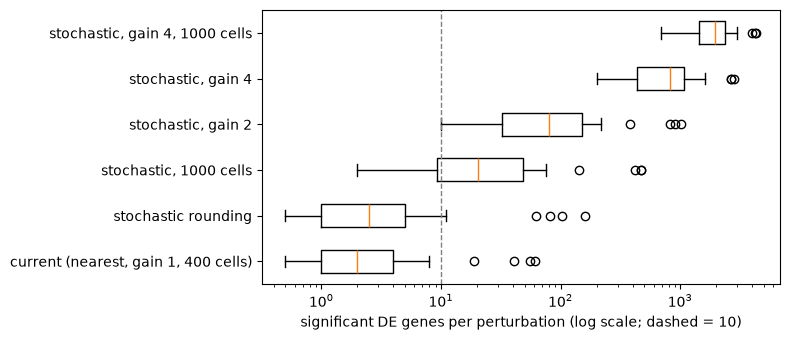

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
order = list(SETTINGS)
ax.boxplot([calls.loc[calls.setting == s, "n_sig"].clip(lower=0.5) for s in order], orientation="horizontal")
ax.set_yticks(range(1, len(order) + 1), order)
ax.set_xscale("log")
ax.axvline(10, color="grey", ls="--", lw=1)
ax.set_xlabel("significant DE genes per perturbation (log scale; dashed = 10)")
plt.tight_layout()
plt.show()

## Step 5 — Reading the results and choosing a setting

**What you want:** `frac_ge_10` in roughly the 0.70–0.87 range, with `agree` close to 1.

* **`current` far below that** → under-calling confirmed: that's the FID problem.
* **Stochastic rounding** is the safe first change: it doesn't change any expected count, it only
  stops rounding from erasing small effects. If it alone reaches the target range, use it.
* **`gain`** makes effects bigger than the model fitted. It raises the number of calls, but if the
  model's directions are wrong, it also makes MSE and NMAE worse (those are scored on the
  same cells). Use the smallest gain that reaches the target range. You can check its cost on
  MSE/NMAE locally by adding a predictor to `run_fold` in `validate_loco.ipynb`, e.g.
  `"gain2": 2 * predictors["model"]` (target genes are masked there anyway).
* **More cells** adds power without changing any effect, but makes the file bigger
  (~4 GB per 400 cells per perturbation). Prefer it over a large gain if it gets you there.
* **Low `agree`** (say < 0.8) means many calls are noise rather than the model's prediction:
  back off that setting.

Over-calling is penalized too ($\max(n_\text{pred}, n_\text{real})$ in the denominator), so
don't push `frac_ge_10` toward 1.

**This only calibrates the *number* of calls.** Whether they're the right genes in the right
direction depends on the model, and only the leaderboard can tell. Submit the chosen setting
once and compare FID with your previous entries.

## Step 6 — Submitting the chosen setting

In `calculate_predictions_log2_fc.ipynb`, pass the setting to `write_submission`:

```python
model_obj.write_submission(
    'pc_linreg_log2_fidfix.h5ad', contexts_and_data, target_genes_by_context,
    knockdown_fraction=kd, alpha=1.0,
    rounding="stochastic", gain=..., cells_per_pert=...,
)
```

Change one thing at a time between submissions so the leaderboard tells you which change mattered.